## 1. Генерация выборок

Генерируется по 500 наблюдений из каждого распределения.

Нормальное распределение задаётся параметрами сдвига и масштаба, причём
`scale` - это стандартное отклонение σ, а не дисперсия σ².

Биномиальная величина B(10, 0.5) описывает число успехов в 10 независимых
испытаниях с вероятностью успеха 0.5 и принимает только целые значения
от 0 до 10. Число испытаний хранится в переменной `n_trials`, чтобы не
путать его с объёмом выборки `n = 500`.

Для воспроизводимости зафиксирован seed = 42: при каждом запуске
генератор выдаёт одну и ту же последовательность чисел.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
rng = np.random.default_rng(42)
n = 500
mu, sigma = 0, 1
sample_normal = rng.normal(loc=mu, scale=sigma, size=n)
n_trials, p = 10, 0.5
sample_binom = rng.binomial(n=n_trials, p=p, size=n)

Столбчатая диаграмма эмпирических частот биномиального распределения
с наложенными теоретическими вероятностями приведена в п. 3 «Визуализация».

## 2. Вычисление статистик

Для каждой выборки вычисляется восемь характеристик встроенными функциями
NumPy и SciPy и сравнивается их с теоретическими значениями распределений.

Для дисперсии и стандартного отклонения указан параметр `ddof=1`
(деление на n−1).
Теоретические значения:
- для N(μ, σ²) среднее и медиана равны μ, дисперсия σ², асимметрия
  и эксцесс равны нулю в силу симметрии распределения;
- для B(m, p) среднее равно m·p = 5, дисперсия m·p·(1−p) = 2.5,
  асимметрия (1−2p)/√(m·p·q) при p = 0.5 обращается в ноль,
  эксцесс (1−6pq)/(mpq) = −0.2, то есть распределение немного более
  плоское, чем нормальное.

Квартили теоретических распределений получены через функцию, обратную
к функции распределения (`ppf`).

In [12]:
def sample_stats(x):
    return {
        "Среднее": np.mean(x),
        "Дисперсия": np.var(x, ddof=1),
        "Стандартное отклонение": np.std(x, ddof=1),
        "Медиана": np.median(x),
        "Q1": np.percentile(x, 25),
        "Q3": np.percentile(x, 75),
        "Асимметрия": stats.skew(x),
        "Эксцесс": stats.kurtosis(x),
    }

theory_normal = {
    "Среднее": mu,
    "Дисперсия": sigma**2,
    "Стандартное отклонение": sigma,
    "Медиана": mu,
    "Q1": stats.norm.ppf(0.25, mu, sigma),
    "Q3": stats.norm.ppf(0.75, mu, sigma),
    "Асимметрия": 0.0,
    "Эксцесс": 0.0,
}

q = 1 - p
theory_binom = {
    "Среднее": n_trials * p,
    "Дисперсия": n_trials * p * q,
    "Стандартное отклонение": np.sqrt(n_trials * p * q),
    "Медиана": stats.binom.ppf(0.50, n_trials, p),
    "Q1": stats.binom.ppf(0.25, n_trials, p),
    "Q3": stats.binom.ppf(0.75, n_trials, p),
    "Асимметрия": (1 - 2*p) / np.sqrt(n_trials * p * q),
    "Эксцесс": (1 - 6*p*q) / (n_trials * p * q),
}

In [13]:
def comparison_table(sample, theory, name):
    df = pd.DataFrame({
        "Теоретическое": pd.Series(theory),
        "Выборочное": pd.Series(sample_stats(sample)),
    })
    df["Отклонение"] = df["Выборочное"] - df["Теоретическое"]
    df.index.name = name
    return df.round(4)

table_normal = comparison_table(sample_normal, theory_normal, f"N({mu}, {sigma}²)")
table_binom = comparison_table(sample_binom, theory_binom, f"B({n_trials}, {p})")

display(table_normal)
display(table_binom)

,Теоретическое,Выборочное,Отклонение
"N(0, 1²)",,,
Среднее,0.0000,-0.0131,-0.0131
Дисперсия,1.0000,0.9215,-0.0785
Стандартное отклонение,1.0000,0.9599,-0.0401
Медиана,0.0000,0.0032,0.0032
Q1,-0.6745,-0.6669,0.0076
Q3,0.6745,0.5874,-0.0871
Асимметрия,0.0000,0.0934,0.0934
Эксцесс,0.0000,-0.0516,-0.0516


,Теоретическое,Выборочное,Отклонение
"B(10, 0.5)",,,
Среднее,5.0000,4.9840,-0.0160
Дисперсия,2.5000,2.7693,0.2693
Стандартное отклонение,1.5811,1.6641,0.0830
Медиана,5.0000,5.0000,0.0000
Q1,4.0000,4.0000,0.0000
Q3,6.0000,6.0000,0.0000
Асимметрия,0.0000,0.0019,0.0019
Эксцесс,-0.2000,-0.2664,-0.0664


### 2.2. Собственная реализация статистик

Реализованы те же характеристики вручную с использованием только `np.sum` и `np.sort`,
и сравним со встроенными функциями.

В асимметрии и эксцессе стандартное отклонение берётся с `ddof=0`
(деление на n), поскольку именно так его вычисляют `scipy.stats.skew`
и `kurtosis`. Квартили считаются методом линейной интерполяции -
тем же, что используется в `np.percentile` по умолчанию.

In [5]:
def new_mean(x):
    return np.sum(x) / len(x)

def new_var(x, ddof=1):
    n = len(x)
    m = new_mean(x)
    return np.sum((x - m) ** 2) / (n - ddof)

def new_std(x, ddof=1):
    return new_var(x, ddof) ** 0.5

def new_skew(x):
    n = len(x)
    m = new_mean(x)
    s = new_std(x, ddof=0)
    return np.sum(((x - m) / s) ** 3) / n

def new_kurtosis(x):
    s = new_std(x, ddof=0)
    m = new_mean(x)
    n = len(x)
    return np.sum(((x - m) / s) ** 4) / n - 3


def new_median(x):
    s = np.sort(x)
    n_len = len(s)
    mid = n_len // 2
    if n_len % 2 == 1:
        return float(s[mid])
    return float((s[mid - 1] + s[mid]) / 2)

def new_percentile(x, q):
    s = np.sort(x)
    n_len = len(s)
    high = (n_len - 1) * q / 100
    low  = int(high)
    frac = high - low
    if low + 1 >= n_len:
        return float(s[low])
    return float (s[low] + frac * (s[low + 1] - s[low]))

In [14]:
def new_stats(x):
    return {
        "Среднее": new_mean(x),
        "Дисперсия": new_var(x, ddof=1),
        "Стандартное отклонение": new_std(x, ddof=1),
        "Медиана": new_median(x),
        "Q1": new_percentile(x, 25),
        "Q3": new_percentile(x, 75),
        "Асимметрия": new_skew(x),
        "Эксцесс": new_kurtosis(x),
    }

def check_table(sample, name):
    df = pd.DataFrame({
        "custom_func": pd.Series(new_stats(sample)),
        "builtin": pd.Series(sample_stats(sample)),
    })
    df["difference"] = df["custom_func"] - df["builtin"]
    df.index.name = name
    return df

display(check_table(sample_normal, "Нормальное").round(10))
display(check_table(sample_binom, "Биномиальное").round(10))

,custom_func,builtin,difference
Нормальное,,,
Среднее,-0.013126,-0.013126,0.0
Дисперсия,0.921474,0.921474,0.0
Стандартное отклонение,0.959934,0.959934,0.0
Медиана,0.003212,0.003212,0.0
Q1,-0.666917,-0.666917,0.0
Q3,0.587393,0.587393,0.0
Асимметрия,0.093409,0.093409,0.0
Эксцесс,-0.051650,-0.051650,0.0


,custom_func,builtin,difference
Биномиальное,,,
Среднее,4.984000,4.984000,0.0
Дисперсия,2.769283,2.769283,0.0
Стандартное отклонение,1.664116,1.664116,0.0
Медиана,5.000000,5.000000,0.0
Q1,4.000000,4.000000,0.0
Q3,6.000000,6.000000,0.0
Асимметрия,0.001886,0.001886,0.0
Эксцесс,-0.266360,-0.266360,-0.0


## 3. Визуализация

Строится гистограмма нормальной выборки с нормировкой на плотность
(`density=True`) и накладывается теоретическая кривая, а для биномиального
распределения - столбчатая диаграмма эмпирических частот с теоретическими
вероятностями P(X = k). 
Для биномиального распределения гистограмма неприменима: величина
принимает только целые значения, и разбиение на интервалы не имеет
смысла. Вместо неё строится столбчатая диаграмма эмпирических частот -
доли каждого значения в выборке, и накладываются теоретические
вероятности P(X = k). Они изображены точками, а не линией, поскольку
между соседними целыми значениями дискретная величина ничего
не принимает.

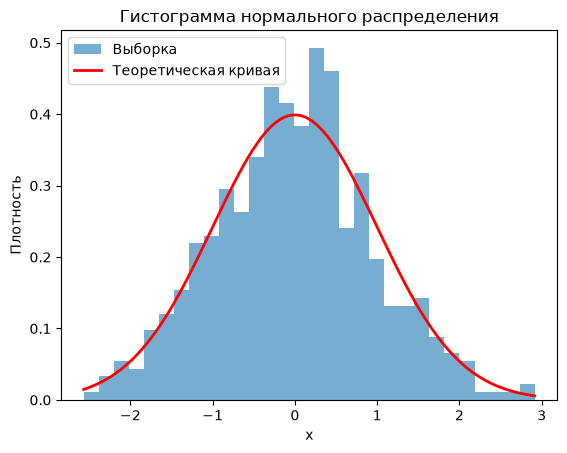

In [16]:
x = np.linspace(sample_normal.min(), sample_normal.max(), 300)

plt.hist(sample_normal, bins=30, density=True, alpha=0.6, label="Выборка")
plt.plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=2, label="Теоретическая кривая")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Гистограмма нормального распределения")
plt.legend()
plt.show()

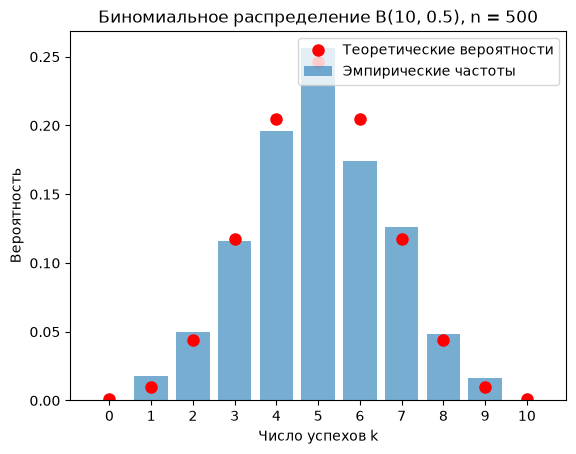

In [8]:
k = np.arange(0, n_trials + 1)
counts = np.bincount(sample_binom, minlength=n_trials + 1)
freq = counts / n
pmf = stats.binom.pmf(k, n_trials, p)
plt.bar(k, freq, alpha=0.6, label='Эмпирические частоты')
plt.plot(k, pmf, "ro", ms=8, label="Теоретические вероятности")
plt.xlabel("Число успехов k")
plt.ylabel("Вероятность")
plt.title(f"Биномиальное распределение B({n_trials}, {p}), n = {n}")
plt.xticks(k)
plt.legend()
plt.show()

## 4. Имитационное моделирование (закон больших чисел)

Эксперимент проводится для нормального распределения, у которого
теоретическое математическое ожидание равно нулю.

Перебираются размеры выборки n от 1 до 1000 с шагом 10 - всего
100 значений. Для каждого n генерируется выборка и вычисляется ее среднее.
Весь перебор повторяется 50 раз => получается 50 независимых траекторий.

Результаты хранятся в матрице `means` размером 50 * 100: строка - одно
повторение эксперимента, столбец - один размер выборки. Такая структура
позволяет получить из неё и сами траектории, и разброс
средних при фиксированном n для второго графика.

In [27]:
n_values = np.arange(1, 1001, 10)
n_repeats = 1

means = np.empty((n_repeats, len(n_values)))

for i in range(n_repeats):
    for j, n_cur in enumerate(n_values):
        means[i, j] = rng.normal(loc=mu, scale=sigma, size=n_cur).mean()

print("Размер матрицы результатов:", means.shape)

Размер матрицы результатов: (1, 100)


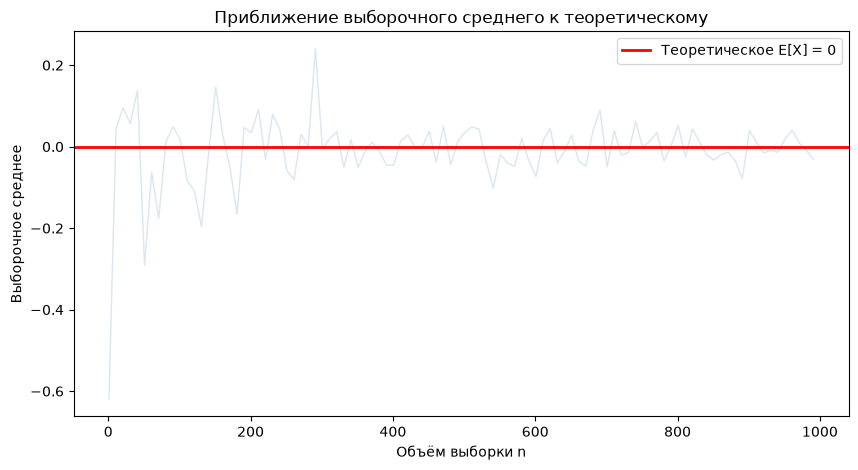

In [28]:
plt.figure(figsize=(10, 5))

for i in range(n_repeats):
    plt.plot(n_values, means[i], color="steelblue", alpha=0.2, lw=1)

plt.axhline(mu, color="red", lw=2, label=f"Теоретическое E[X] = {mu}")

plt.xlabel("Объём выборки n")
plt.ylabel("Выборочное среднее")
plt.title("Приближение выборочного среднего к теоретическому")
plt.legend()
plt.show()

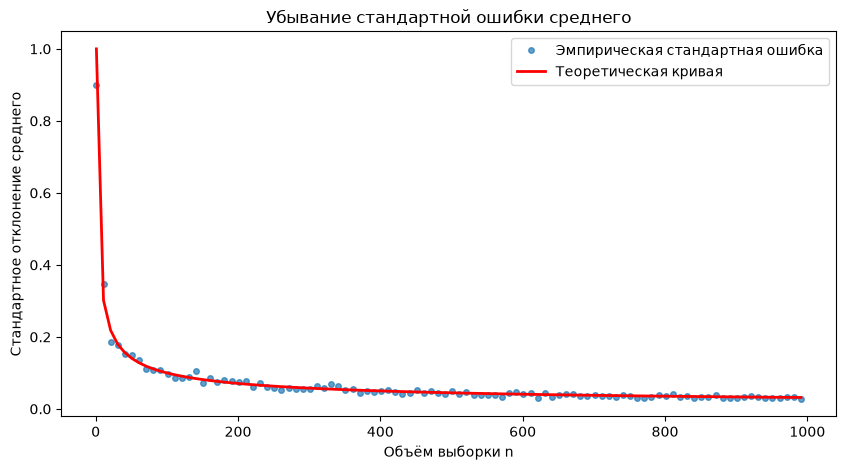

In [20]:
se_empirical = means.std(axis=0, ddof=1)
se_theory = sigma / np.sqrt(n_values)

plt.figure(figsize=(10, 5))
plt.plot(n_values, se_empirical, "o", ms=4, alpha=0.7, label="Эмпирическая стандартная ошибка")
plt.plot(n_values, se_theory, "r-", lw=2, label=r"Теоретическая кривая")
plt.xlabel("Объём выборки n")
plt.ylabel("Стандартное отклонение среднего")
plt.title("Убывание стандартной ошибки среднего")
plt.legend()
plt.show()

**Вывод о сходимости.** На первом графике траектории образуют характерную
воронку: при малых n выборочные средние разбросаны широко, отклоняясь
от нуля на единицы, а с ростом n размах колебаний затухает и все траектории
стягиваются к теоретическому математическому ожиданию E[X] = 0. Это и есть
визуализация закона больших чисел.

Второй график показывает, что эмпирическое стандартное отклонение среднего
ложится на теоретическую кривую σ/√n. Убывание идёт как корень из n,
а не пропорционально n: чтобы уменьшить ошибку вдвое, объём выборки
нужно увеличить вчетверо.

## 5. Выводы

**Согласование с теорией.** Выборочные характеристики обеих выборок
близки к теоретическим. Для N(0, 1) медиана составила 0.003 при
теоретическом значении 0, дисперсия 0.921 против 1. Для B(10, 0.5)
среднее равно 4.984 против теоретических 5, эксцесс −0.266 против −0.2.
Наблюдаемые отклонения объясняются конечностью выборки и не выходят
за пределы случайного разброса.

Заметно, что асимметрия и эксцесс сходятся к теоретическим значениям
медленнее, чем среднее: они зависят от третьей и четвёртой степеней
отклонений и потому сильнее реагируют на редкие крайние наблюдения.

**Влияние объёма выборки.** Точность оценок растёт пропорционально √n.
Это видно на графике стандартной ошибки: при n = 100 разброс средних
составляет около 0.1, а при n = 1000 - около 0.03.

**Проверка собственных функций.** Все восемь характеристик, вычисленных
вручную, совпали со встроенными; расхождения находятся на уровне
машинной точности (порядка 1e-16), что подтверждает корректность реализации.

**Закон больших чисел** демонстрируется сходимостью выборочного среднего
к математическому ожиданию при росте объёма выборки: отдельные траектории
продолжают колебаться, но амплитуда колебаний стремится к нулю.